# JFCNN Training — Productive vs Waste

Trains the Joint Semantic + Structural CNN on the labeled page corpus.

**Pipeline**
1. Load labeled records from SQLite, drop `skip`
2. Build vocab + GloVe / structural embedding matrices
3. Stratified 80/20 train/val split
4. Train with Adam + CrossEntropyLoss
5. Evaluate: accuracy, precision, recall, F1, AUC
6. Save model weights + vocab artifacts to `checkpoints/`

> **Note — small dataset**: after dropping `skip`, the corpus currently has ~19 pages.
> All metrics on a 4-sample val set are high-variance. Treat them as sanity checks
> until the corpus grows.

In [22]:
import sys
sys.path.insert(0, '.')

import json
import os
import pickle
import random

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import config
from semantic_structure.db import load_records
from semantic_structure.extractor import build_corpus_vocab
from semantic_structure.dataset import PageDataset
from semantic_structure.model import JFCNN


# ── Visualization imports & shared config ────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc as roc_auc_curve,
    precision_recall_curve, average_precision_score,
)
import pandas as pd

print('Imports OK')

Imports OK


## Hyperparameters

In [23]:
# ── Data ───────────────────────────────────────────────────────────────────
VAL_SPLIT    = 0.10      # fraction of data held out for validation
TEST_SPLIT   = 0.20      # fraction of data held out for final test
SEED         = 42

# ── Model ──────────────────────────────────────────────────────────────────
NUM_FILTERS  = 128       # conv filters per kernel size
KERNEL_SIZES = [3, 4, 5] # parallel conv towers
FC_HIDDEN    = 256
DROPOUT      = 0.5
# TODO: set FREEZE_WORD_EMB=False to fine-tune GloVe weights once the
#       corpus is large enough (>1 k labeled pages recommended).
FREEZE_WORD_EMB = False

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE   = 32
NUM_EPOCHS   = 500
LR           = 1e-3
WD           = 1e-4
INTERVAL     = 10       # Epoch Interval to output training diagnostics
# ── Paths ──────────────────────────────────────────────────────────────────
CHECKPOINT_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'models', 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

print(f'Device:          {DEVICE}')
print(f'Checkpoint dir:  {CHECKPOINT_DIR}')

Device:          mps
Checkpoint dir:  /Users/umair/mlops/models/checkpoints


## 1. Load data + build vocab

In [24]:
from collections import Counter

all_records = load_records(config.DB_PATH)
print(f'Total labeled records: {len(all_records)}')
print(f'Label breakdown: {dict(Counter(r[2] for r in all_records))}')

# build_corpus_vocab uses ALL records (including skip) for vocabulary coverage,
# then PageDataset drops skip rows at construction time.
token2idx, word_matrix, struct_matrix = build_corpus_vocab(
    all_records, config.GLOVE_PATH, config.N, config.M
)

k = word_matrix.shape[1]
print(f'\nVocab size:  {len(token2idx)}')
print(f'k (GloVe):   {k}')
print(f'n (struct):  {config.N}')
print(f'Input dim:   {k + config.N}  (k+n per token)')

Total labeled records: 915
Label breakdown: {'waste': 438, 'productive': 474, 'skip': 3}
Parsing HTML corpus ...


  0%|          | 0/915 [00:00<?, ?page/s]

100%|██████████| 915/915 [00:05<00:00, 160.05page/s]


Loading GloVe from /Users/umair/mlops/models/semantic_structure/GloVe/dolma_300_2024_1.2M.100_combined.txt ...


1200000 lines [00:10, 119540.16 lines/s]

GloVe dimension: 300
Vocab: 20441 tokens | GloVe coverage: 17633/20439 (86.3%)

Vocab size:  20441
k (GloVe):   300
n (struct):  16
Input dim:   316  (k+n per token)


## 2. Dataset + stratified train/val split

In [25]:
dataset = PageDataset(
    records   = all_records,
    token2idx = token2idx,
    tag2idx   = config.TAG_TO_IDX,
    label2idx = config.LABEL_TO_IDX,
    m         = config.M,
)

print(f'Dataset size after dropping skip: {len(dataset)}')
label_counts = Counter(dataset.records[i][2] for i in range(len(dataset)))
print(f'Label breakdown: {dict(label_counts)}')

# Stratified 70/10/20 train/val/test split
rng = random.Random(SEED)

by_class = {}
for i, (_, _, label_str) in enumerate(dataset.records):
    by_class.setdefault(label_str, []).append(i)

train_indices, val_indices, test_indices = [], [], []
for label_str, indices in by_class.items():
    rng.shuffle(indices)
    n_test = max(1, round(len(indices) * TEST_SPLIT))
    n_val  = max(1, round(len(indices) * VAL_SPLIT))
    test_indices.extend(indices[:n_test])
    val_indices.extend(indices[n_test:n_test + n_val])
    train_indices.extend(indices[n_test + n_val:])

rng.shuffle(train_indices)
rng.shuffle(val_indices)
rng.shuffle(test_indices)

train_set = Subset(dataset, train_indices)
val_set   = Subset(dataset, val_indices)
test_set  = Subset(dataset, test_indices)

print(f'\nTrain: {len(train_set)} samples (70%)')
print(f'Val:   {len(val_set)} samples (10%)')
print(f'Test:  {len(test_set)} samples (20%)')

Dataset size after dropping skip: 912
Label breakdown: {'waste': 438, 'productive': 474}

Train: 638 samples (70%)
Val:   91 samples (10%)
Test:  183 samples (20%)


In [26]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 20
Val batches:   3
Test batches:  6


## 3. Build model

In [27]:
torch.manual_seed(SEED)

model = JFCNN(
    word_matrix    = word_matrix,
    struct_matrix  = struct_matrix,
    num_filters    = NUM_FILTERS,
    kernel_sizes   = KERNEL_SIZES,
    fc_hidden      = FC_HIDDEN,
    dropout        = DROPOUT,
    num_classes    = 2,
    freeze_word_emb = FREEZE_WORD_EMB,
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal params:     {total:,}')
print(f'Trainable params: {trainable:,}')

JFCNN(
  (word_emb): Embedding(20441, 300, padding_idx=0)
  (struct_emb): Embedding(13, 16, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(316, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(316, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(316, 128, kernel_size=(5,), stride=(1,))
  )
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)

Total params:     6,717,342
Trainable params: 6,717,342


## 4. Optimizer + loss

In [28]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
criterion = nn.CrossEntropyLoss()  # applies log-softmax internally

## 5. Training loop

In [29]:
def evaluate(model, loader, criterion, device):
    """Run one pass over loader, return loss + all metrics."""
    model.eval()
    all_labels = []
    all_preds  = []
    all_probs  = []   # P(waste) for AUC
    total_loss = 0.0

    with torch.no_grad():
        for word_idx, tag_idx, labels in loader:
            word_idx = word_idx.to(device)
            tag_idx  = tag_idx.to(device)
            labels   = labels.to(device)

            logits = model(word_idx, tag_idx)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * len(labels)

            probs = torch.softmax(logits, dim=-1)[:, 1]  # P(waste)
            preds = logits.argmax(dim=-1)

            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    n = len(all_labels)
    avg_loss  = total_loss / n
    accuracy  = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall    = recall_score(all_labels, all_preds, zero_division=0)
    f1        = f1_score(all_labels, all_preds, zero_division=0)
    # AUC requires at least one sample from each class in the split
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')

    return dict(loss=avg_loss, accuracy=accuracy,
                precision=precision, recall=recall, f1=f1, auc=auc)


history = []

print(f'{'Epoch':>6}  {'Train Loss':>10}  {'Val Loss':>8}  {'Acc':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'AUC':>6}')
print('-' * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for word_idx, tag_idx, labels in train_loader:
        word_idx = word_idx.to(DEVICE)
        tag_idx  = tag_idx.to(DEVICE)
        labels   = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(word_idx, tag_idx)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(labels)

    train_loss /= len(train_set)

    # ── Validate ───────────────────────────────────────────────────────────
    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    history.append({'epoch': epoch, 'train_loss': train_loss, **val_metrics})

    if epoch % INTERVAL == 0 or epoch == 1:
        print(
            f'{epoch:>6}  {train_loss:>10.4f}  '
            f'{val_metrics["loss"]:>8.4f}  '
            f'{val_metrics["accuracy"]:>6.3f}  '
            f'{val_metrics["precision"]:>6.3f}  '
            f'{val_metrics["recall"]:>6.3f}  '
            f'{val_metrics["f1"]:>6.3f}  '
            f'{val_metrics["auc"]:>6.3f}'
        )

print('\nTraining complete.')

 Epoch  Train Loss  Val Loss     Acc    Prec     Rec      F1     AUC
---------------------------------------------------------------------------
     1      0.6499    0.5168   0.703   0.840   0.477   0.609   0.898
     5      0.1930    0.2414   0.912   0.875   0.955   0.913   0.961
    10      0.1563    0.2472   0.890   0.840   0.955   0.894   0.961
    15      0.1385    0.2508   0.923   0.878   0.977   0.925   0.962
    20      0.1253    0.3438   0.868   0.864   0.864   0.864   0.960
    25      0.1305    0.3301   0.868   0.808   0.955   0.875   0.955
    30      0.1238    0.3673   0.879   0.884   0.864   0.874   0.958
    35      0.1074    0.2927   0.890   0.854   0.932   0.891   0.950
    40      0.1146    0.3090   0.912   0.875   0.955   0.913   0.950
    45      0.1258    0.4098   0.857   0.792   0.955   0.866   0.920
    50      0.1147    0.2841   0.890   0.854   0.932   0.891   0.949
    55      0.1111    0.2998   0.901   0.857   0.955   0.903   0.946
    60      0.1109    0.331

## 6. Final evaluation

In [30]:
final = evaluate(model, test_loader, criterion, DEVICE)

print('Test metrics (final epoch)')
print('-' * 30)
for name, test in final.items():
    print(f'  {name:12s}: {test:.4f}')

Test metrics (final epoch)
------------------------------
  loss        : 0.6043
  accuracy    : 0.8689
  precision   : 0.8721
  recall      : 0.8523
  f1          : 0.8621
  auc         : 0.9434


## 7. Save model + vocab artifacts

In [31]:
test_metrics = final

print('Test metrics (held-out set)')
print('-' * 30)
for name, val in test_metrics.items():
    print(f'  {name:12s}: {val:.4f}')

# Model weights
model_path = os.path.join(CHECKPOINT_DIR, 'jfcnn.pt')
torch.save(model.state_dict(), model_path)
print(f'\nModel weights saved → {model_path}')

# token2idx (needed to tokenise new pages at inference time)
vocab_path = os.path.join(CHECKPOINT_DIR, 'token2idx.json')
with open(vocab_path, 'w') as f:
    json.dump(token2idx, f)
print(f'token2idx saved    → {vocab_path}')

# Embedding matrices (word_matrix is large; struct_matrix is trained)
emb_path = os.path.join(CHECKPOINT_DIR, 'embeddings.npz')
np.savez(emb_path, word_matrix=word_matrix, struct_matrix=struct_matrix)
print(f'Embeddings saved   → {emb_path}')

# Training config for reproducibility
cfg_path = os.path.join(CHECKPOINT_DIR, 'train_config.json')
with open(cfg_path, 'w') as f:
    json.dump(dict(
        num_filters=NUM_FILTERS,
        kernel_sizes=KERNEL_SIZES,
        fc_hidden=FC_HIDDEN,
        dropout=DROPOUT,
        freeze_word_emb=FREEZE_WORD_EMB,
        num_classes=2,
        batch_size=BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        lr=LR,
        seed=SEED,
        val_split=VAL_SPLIT,
        test_split=TEST_SPLIT,
        final_val_metrics=final,
        final_test_metrics=test_metrics,
    ), f, indent=2)
print(f'Train config saved → {cfg_path}')

Test metrics (held-out set)
------------------------------
  loss        : 0.6043
  accuracy    : 0.8689
  precision   : 0.8721
  recall      : 0.8523
  f1          : 0.8621
  auc         : 0.9434

Model weights saved → /Users/umair/mlops/models/checkpoints/jfcnn.pt
token2idx saved    → /Users/umair/mlops/models/checkpoints/token2idx.json
Embeddings saved   → /Users/umair/mlops/models/checkpoints/embeddings.npz
Train config saved → /Users/umair/mlops/models/checkpoints/train_config.json


## 8. Visualizations

Four sections:
1. **Training Dynamics** — loss curves, metric progression, AUC over epochs
2. **Final Results** — confusion matrix, ROC, Precision-Recall, metrics bar chart
3. **Data Exploration** — class balance, token lengths, structural tag frequencies
4. **Interpretability** — gradient saliency for words and HTML tags, CNN filter activations on misclassified pages

### 8.0 — Visualization Imports & Config

In [41]:
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
CLASS_NAMES = ['Productive', 'Waste']


### 8.1 — Training Dynamics
**1A** Train vs Val Loss · **1B** Metric Curves (Accuracy, F1, Precision, Recall) · **1C** AUC-ROC Over Epochs

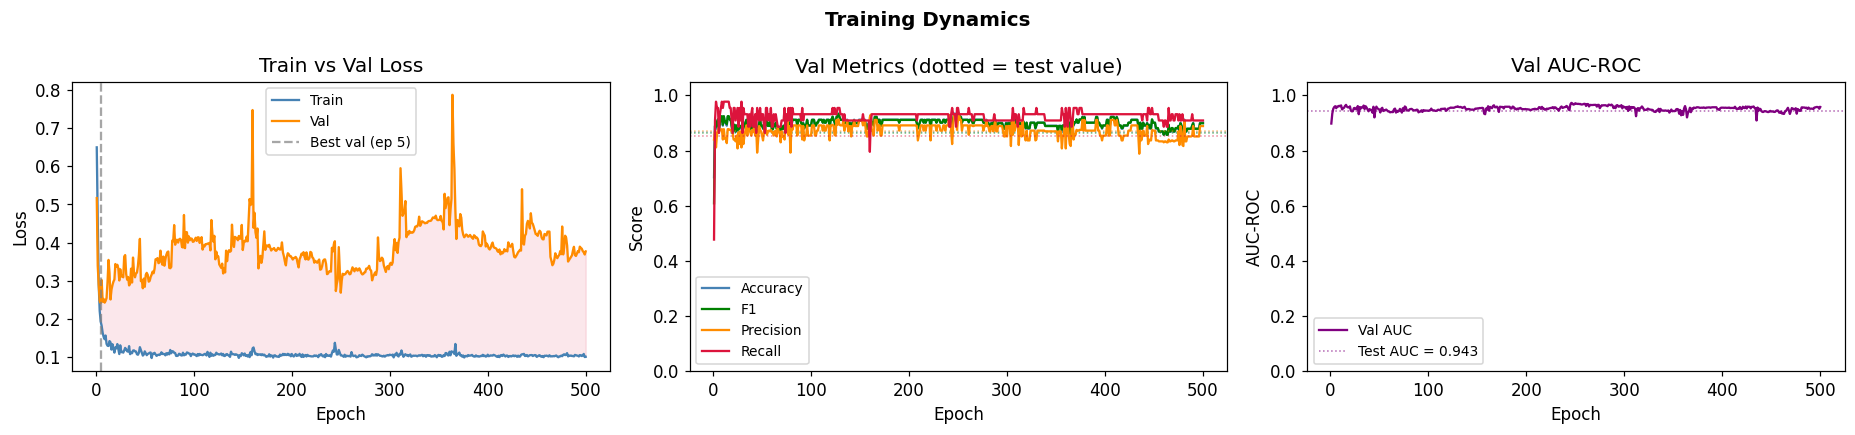

In [42]:

# ── Section 1: Training Dynamics ─────────────────────────────────────────────
epochs_list = [h['epoch'] for h in history]
train_loss  = [h['train_loss'] for h in history]
val_loss    = [h['loss'] for h in history]
best_ep     = epochs_list[int(np.argmin(val_loss))]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Training Dynamics', fontsize=13, fontweight='bold')

# 1A — Train vs Val loss
ax = axes[0]
ax.plot(epochs_list, train_loss, label='Train', color='steelblue', lw=1.5)
ax.plot(epochs_list, val_loss,   label='Val',   color='darkorange', lw=1.5)
ax.fill_between(epochs_list, train_loss, val_loss, alpha=0.1, color='crimson')
ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.7, label=f'Best val (ep {best_ep})')
ax.set(xlabel='Epoch', ylabel='Loss', title='Train vs Val Loss')
ax.legend(fontsize=9)

# 1B — Metric curves with dotted test reference lines
ax = axes[1]
metric_cfg = [
    ('accuracy',  'Accuracy',  'steelblue'),
    ('f1',        'F1',        'green'),
    ('precision', 'Precision', 'darkorange'),
    ('recall',    'Recall',    'crimson'),
]
for key, label, color in metric_cfg:
    vals = [h[key] for h in history]
    ax.plot(epochs_list, vals, label=label, color=color, lw=1.5)
    ax.axhline(final[key], color=color, linestyle=':', alpha=0.5, linewidth=1)
ax.set(xlabel='Epoch', ylabel='Score', title='Val Metrics (dotted = test value)',
       ylim=[0, 1.05])
ax.legend(fontsize=9)

# 1C — AUC over training
ax = axes[2]
auc_vals = [h['auc'] for h in history]
ax.plot(epochs_list, auc_vals, color='purple', lw=1.5, label='Val AUC')
ax.axhline(final['auc'], color='purple', linestyle=':', alpha=0.6, linewidth=1,
           label=f'Test AUC = {final["auc"]:.3f}')
ax.set(xlabel='Epoch', ylabel='AUC-ROC', title='Val AUC-ROC', ylim=[0, 1.05])
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_dynamics.png'), bbox_inches='tight')
plt.show()


### 8.2 — Final Test Results (helper)
Extends `evaluate()` to return raw label/prediction/probability arrays needed by the plots below.

In [43]:

# ── evaluate_with_preds: returns raw arrays for plotting ────────────────────
def evaluate_with_preds(model, loader, criterion, device):
    """Like evaluate() but also returns raw labels, predictions, and probabilities."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for word_idx, tag_idx, labels in loader:
            word_idx = word_idx.to(device)
            tag_idx  = tag_idx.to(device)
            labels   = labels.to(device)
            logits   = model(word_idx, tag_idx)
            total_loss += criterion(logits, labels).item() * len(labels)
            all_probs.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().tolist())
            all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    n = len(all_labels)
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)
    metrics = dict(
        loss=total_loss / n,
        accuracy=accuracy_score(all_labels, all_preds),
        precision=precision_score(all_labels, all_preds, zero_division=0),
        recall=recall_score(all_labels, all_preds, zero_division=0),
        f1=f1_score(all_labels, all_preds, zero_division=0),
        auc=roc_auc_score(all_labels, all_probs),
    )
    return metrics, all_labels, all_preds, all_probs

test_m, test_labels_arr, test_preds_arr, test_probs_arr = evaluate_with_preds(
    model, test_loader, criterion, DEVICE
)
print('Test metrics:', {k: f'{v:.4f}' for k, v in test_m.items()})


Test metrics: {'loss': '0.6043', 'accuracy': '0.8689', 'precision': '0.8721', 'recall': '0.8523', 'f1': '0.8621', 'auc': '0.9434'}


### 8.2 — Final Test Results
**2A** Confusion Matrix · **2B** ROC Curve · **2C** Precision-Recall Curve · **2D** Metrics Bar Chart

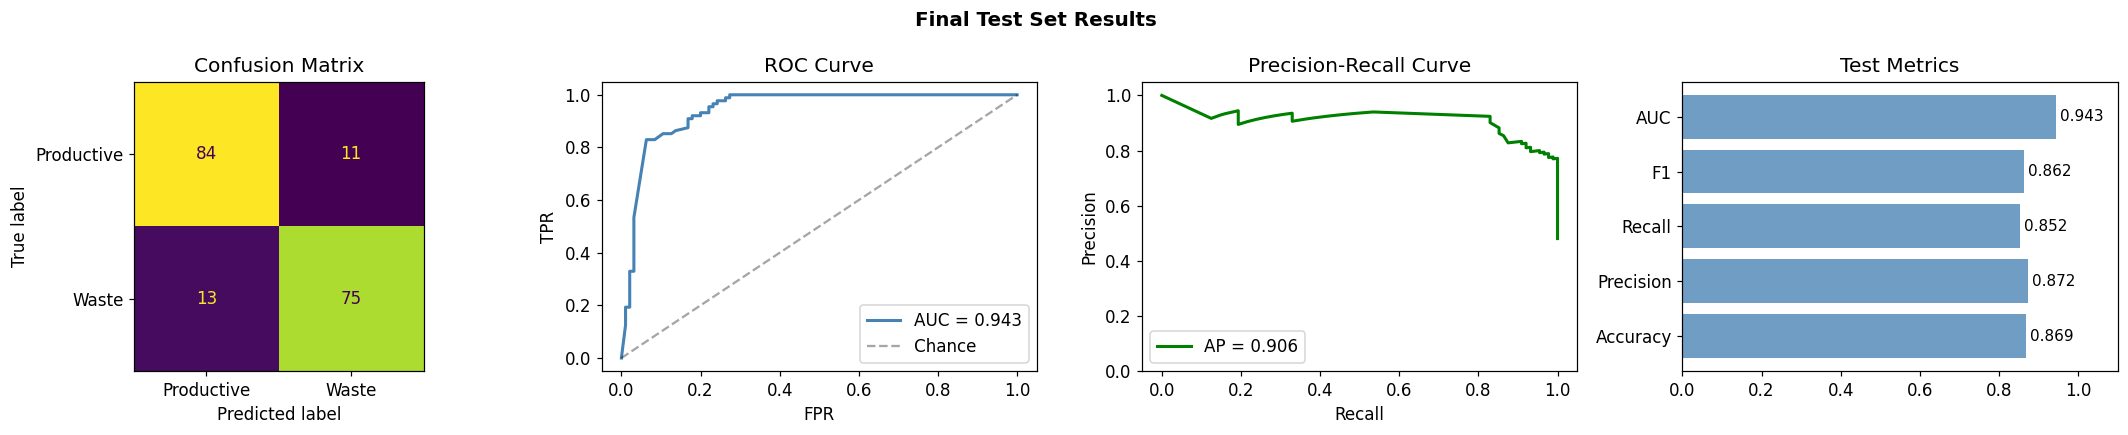

In [44]:

# ── Section 2: Final Results ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Final Test Set Results', fontsize=13, fontweight='bold')

# 2A — Confusion matrix
cm = confusion_matrix(test_labels_arr, test_preds_arr)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# 2B — ROC curve
fpr, tpr, _ = roc_curve(test_labels_arr, test_probs_arr)
roc_val = roc_auc_curve(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.35, label='Chance')
axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[1].legend()

# 2C — Precision-Recall curve
prec_c, rec_c, _ = precision_recall_curve(test_labels_arr, test_probs_arr)
ap = average_precision_score(test_labels_arr, test_probs_arr)
axes[2].plot(rec_c, prec_c, color='green', lw=2, label=f'AP = {ap:.3f}')
axes[2].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve', ylim=[0, 1.05])
axes[2].legend()

# 2D — Metrics bar chart
m_keys   = ['accuracy', 'precision', 'recall', 'f1', 'auc']
m_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
vals = [test_m[k] for k in m_keys]
bars = axes[3].barh(m_labels, vals, color='steelblue', alpha=0.78)
axes[3].set(xlim=[0, 1.1], title='Test Metrics')
for bar, v in zip(bars, vals):
    axes[3].text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'final_results.png'), bbox_inches='tight')
plt.show()


### 8.3 — Data Exploration
**3A** Class Distribution per Split · **3B** Token Sequence Length by Class · **3C** Structural Tag Frequency per Class

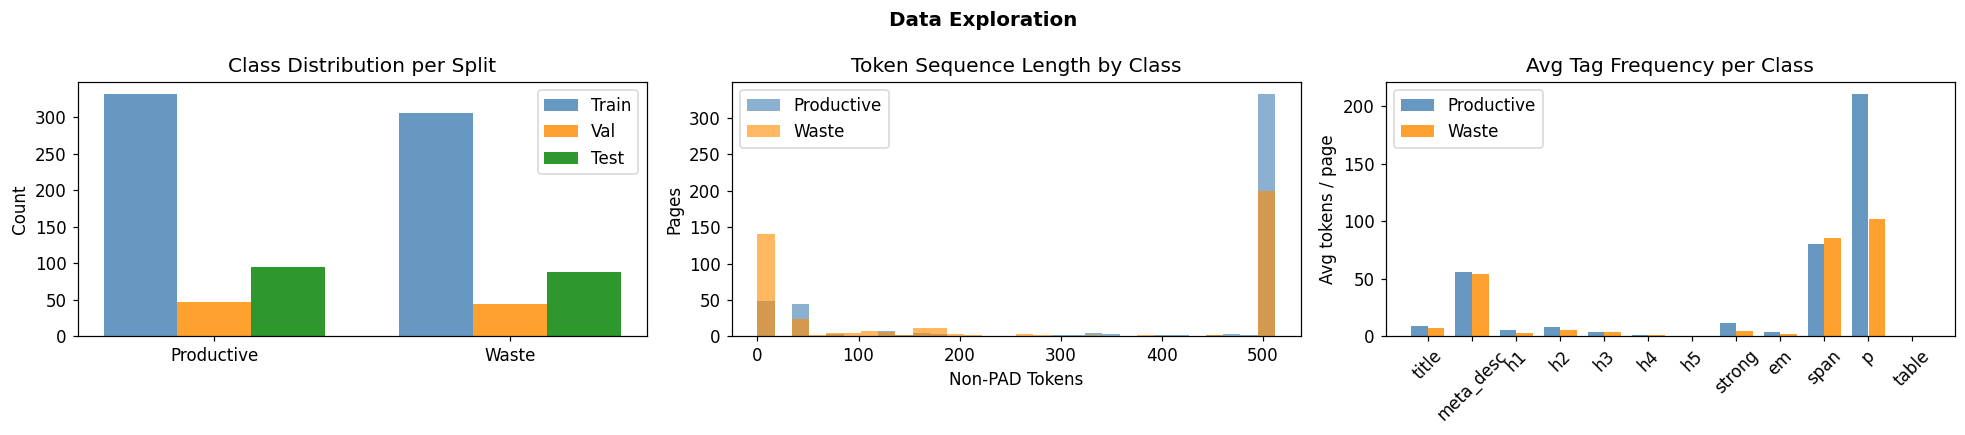

In [45]:

# ── Section 3: Data Exploration ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Data Exploration', fontsize=13, fontweight='bold')

# 3A — Class distribution per split
ax = axes[0]
split_info = [('Train', train_set), ('Val', val_set), ('Test', test_set)]
xpos   = np.arange(len(CLASS_NAMES))
width  = 0.25
colors = ['steelblue', 'darkorange', 'green']
for i, (split_name, subset) in enumerate(split_info):
    counts = [0, 0]
    for idx in subset.indices:
        lbl_str = dataset.records[idx][2]
        counts[config.LABEL_TO_IDX[lbl_str]] += 1
    ax.bar(xpos + i * width, counts, width, label=split_name, color=colors[i], alpha=0.82)
ax.set(xticks=xpos + width, xticklabels=CLASS_NAMES,
       title='Class Distribution per Split', ylabel='Count')
ax.legend()

# 3B — Token sequence length by class
ax = axes[1]
prod_lengths, waste_lengths = [], []
for i in range(len(dataset)):
    word_idx_t, _, label_t = dataset[i]
    length = int((word_idx_t != 0).sum())
    (prod_lengths if label_t.item() == 0 else waste_lengths).append(length)
ax.hist(prod_lengths, bins=30, alpha=0.62, label='Productive', color='steelblue')
ax.hist(waste_lengths, bins=30, alpha=0.62, label='Waste',      color='darkorange')
ax.set(xlabel='Non-PAD Tokens', ylabel='Pages',
       title='Token Sequence Length by Class')
ax.legend()

# 3C — Structural tag frequency per class
ax = axes[2]
tag_names  = config.STRUCTURAL_TAGS
n_tags     = len(tag_names)
prod_freq  = np.zeros(n_tags)
waste_freq = np.zeros(n_tags)
prod_pages = waste_pages = 0
for i in range(len(dataset)):
    _, tag_idx_t, label_t = dataset[i]
    is_prod = label_t.item() == 0
    for t in range(n_tags):
        count = int((tag_idx_t == t + 1).sum())  # tag indices start at 1 (0=PAD)
        if is_prod:
            prod_freq[t] += count
        else:
            waste_freq[t] += count
    if is_prod:
        prod_pages += 1
    else:
        waste_pages += 1
prod_freq  /= prod_pages
waste_freq /= waste_pages

xpos = np.arange(n_tags)
ax.bar(xpos - 0.19, prod_freq,  0.37, label='Productive', color='steelblue',  alpha=0.82)
ax.bar(xpos + 0.19, waste_freq, 0.37, label='Waste',      color='darkorange', alpha=0.82)
ax.set(xticks=xpos, xticklabels=tag_names,
       title='Avg Tag Frequency per Class', ylabel='Avg tokens / page')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'data_exploration.png'), bbox_inches='tight')
plt.show()


### 8.4 — Interpretability: Gradient Saliency Computation
Computes gradient of each class logit w.r.t. word and structural embeddings across the test set.

In [46]:

# ── Section 4: Interpretability — Gradient Saliency Computation ─────────────
def compute_embedding_saliency(model, loader, device):
    """Gradient saliency w.r.t. word and structural embeddings, per output class.

    Returns:
        word_sal: list[dict]  — word_sal[cls][token_id] = avg saliency
        tag_sal:  list[ndarray] — tag_sal[cls] shape (num_tags+1,), index 0 = PAD
    """
    model.eval()
    word_sal = [{} for _ in range(2)]
    tag_sum  = [np.zeros(len(config.STRUCTURAL_TAGS) + 1) for _ in range(2)]
    tag_cnt  = [np.zeros(len(config.STRUCTURAL_TAGS) + 1) for _ in range(2)]

    for wi_b, ti_b, _ in loader:
        wi_b = wi_b.to(device)
        ti_b = ti_b.to(device)

        with torch.no_grad():
            we_base = model.word_emb(wi_b)      # (B, M, k)
            se_base = model.struct_emb(ti_b)    # (B, M, n)

        we = we_base.detach().requires_grad_(True)
        se = se_base.detach().requires_grad_(True)

        # Manual forward — equiv to model.forward in eval mode (dropout is no-op)
        x      = torch.cat([we, se], dim=-1).permute(0, 2, 1)  # (B, k+n, M)
        pooled = [model.relu(conv(x)).max(dim=-1).values for conv in model.convs]
        out    = model.relu(model.fc1(torch.cat(pooled, dim=1)))
        logits = model.fc2(out)

        for cls in range(2):
            if we.grad is not None: we.grad.zero_()
            if se.grad is not None: se.grad.zero_()
            logits[:, cls].sum().backward(retain_graph=(cls == 0))

            w_sal  = we.grad.norm(dim=-1).detach().cpu().numpy()  # (B, M)
            s_sal  = se.grad.norm(dim=-1).detach().cpu().numpy()  # (B, M)
            wi_np  = wi_b.cpu().numpy()
            ti_np  = ti_b.cpu().numpy()

            for b in range(wi_np.shape[0]):
                for t in range(wi_np.shape[1]):
                    wid = int(wi_np[b, t])
                    if wid != 0:
                        word_sal[cls].setdefault(wid, []).append(float(w_sal[b, t]))
                    sid = int(ti_np[b, t])
                    if sid != 0:
                        tag_sum[cls][sid] += float(s_sal[b, t])
                        tag_cnt[cls][sid] += 1

    avg_word = [{wid: float(np.mean(v)) for wid, v in d.items()} for d in word_sal]
    # np.divide with where= skips division where count is 0, avoiding RuntimeWarning
    avg_tag  = [
        np.divide(tag_sum[c], tag_cnt[c], out=np.zeros_like(tag_sum[c]), where=tag_cnt[c] > 0)
        for c in range(2)
    ]
    return avg_word, avg_tag

idx2token_map = {v: k for k, v in token2idx.items()}
print('Computing gradient saliency on test set …')
word_sal_cls, tag_sal_cls = compute_embedding_saliency(model, test_loader, DEVICE)
print(f'Done. Unique tokens with saliency: {len(word_sal_cls[0])} (prod), {len(word_sal_cls[1])} (waste)')


Computing gradient saliency on test set …
Done. Unique tokens with saliency: 8544 (prod), 8544 (waste)


### 8.4 a/b — Interpretability: Word & Tag Saliency Plots
**4A** Top-20 Salient Words per Class · **4B** Structural Tag Saliency per Class

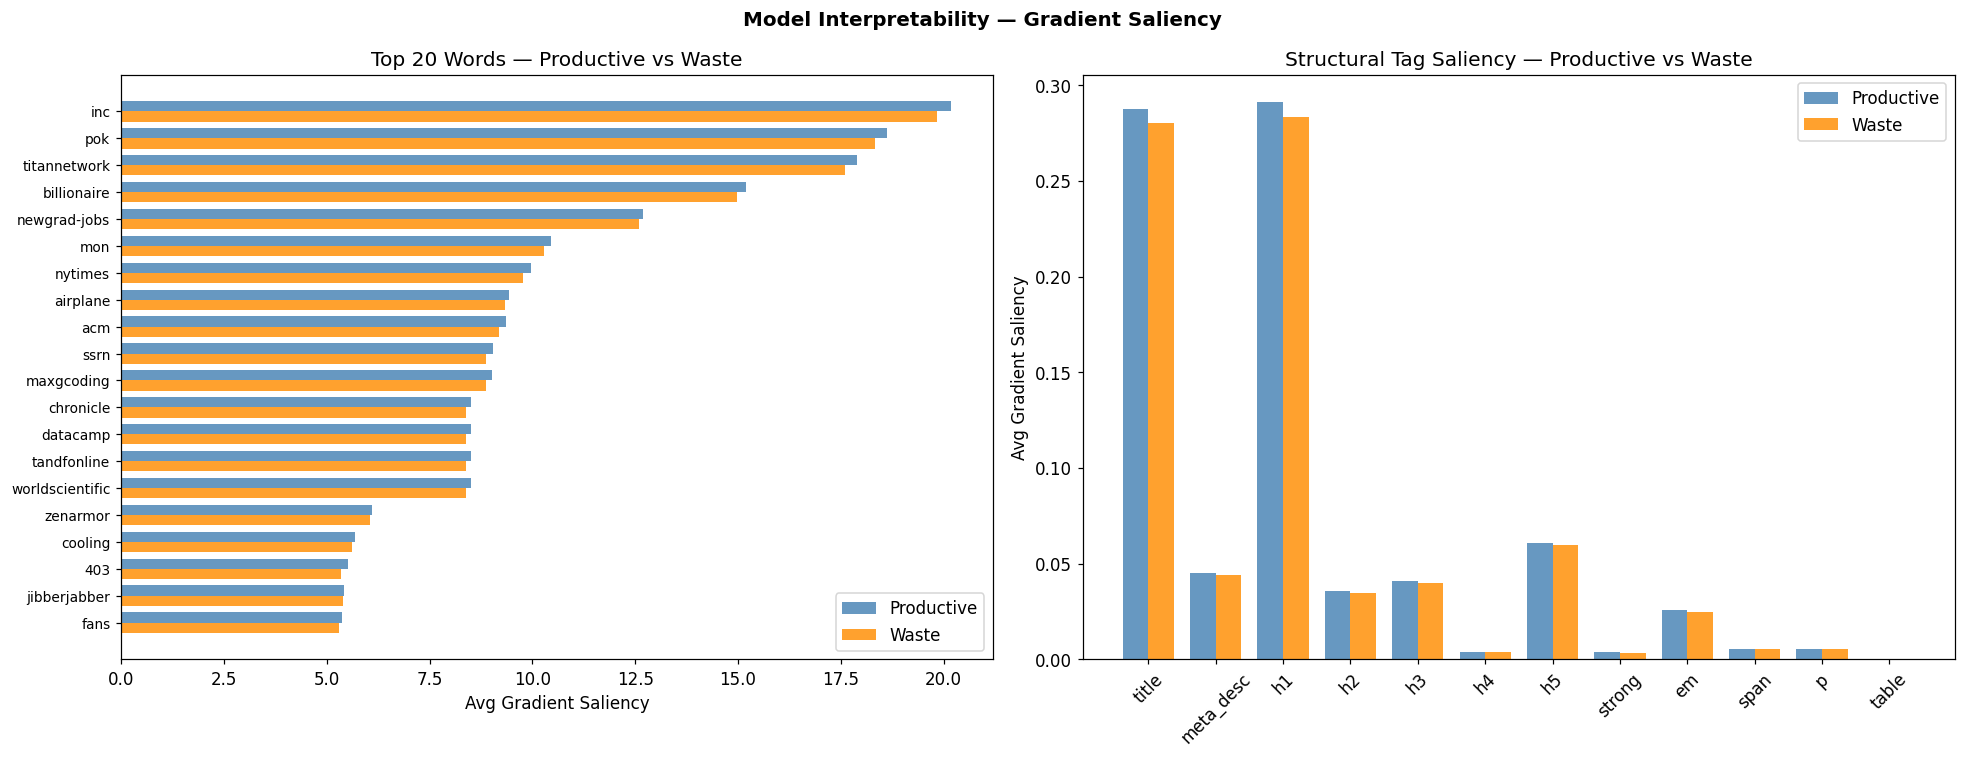

In [47]:
# ── Section 4A+4B: Saliency Plots ───────────────────────────────────────────
TOP_N = 20

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Interpretability — Gradient Saliency', fontsize=13, fontweight='bold')

# 4A — Top words: grouped bars (productive vs waste) sorted by avg saliency
ax = axes[0]
all_wids = set(word_sal_cls[0]) & set(word_sal_cls[1])
word_avg = sorted(
    all_wids,
    key=lambda w: (word_sal_cls[0][w] + word_sal_cls[1][w]) / 2,
    reverse=True
)[:TOP_N]
words  = [idx2token_map.get(w, f'<{w}>') for w in word_avg]
p_vals = [word_sal_cls[0][w] for w in word_avg]
w_vals = [word_sal_cls[1][w] for w in word_avg]

y = np.arange(TOP_N)
h = 0.38
ax.barh(y + h/2, p_vals[::-1], h, label='Productive', color='steelblue',  alpha=0.82)
ax.barh(y - h/2, w_vals[::-1], h, label='Waste',      color='darkorange', alpha=0.82)
ax.set(yticks=y, yticklabels=words[::-1], xlabel='Avg Gradient Saliency',
       title=f'Top {TOP_N} Words — Productive vs Waste')
ax.tick_params(axis='y', labelsize=9)
ax.legend()

# 4B — Tag saliency: grouped bars
ax = axes[1]
tag_names = config.STRUCTURAL_TAGS
x = np.arange(len(tag_names))
w = 0.38
ax.bar(x - w/2, tag_sal_cls[0][1:], w, label='Productive', color='steelblue',  alpha=0.82)
ax.bar(x + w/2, tag_sal_cls[1][1:], w, label='Waste',      color='darkorange', alpha=0.82)
ax.set(xticks=x, xticklabels=tag_names, ylabel='Avg Gradient Saliency',
       title='Structural Tag Saliency — Productive vs Waste')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'saliency.png'), bbox_inches='tight')
plt.show()


### 8.4b(ii) — Interpretability: Contrastive Word Saliency
Ranks words by the **difference** between their waste and productive saliency scores. Words far above the diagonal are genuinely class-discriminative; words near it activate equally for both classes.


▲ Top 20 → WASTE       (diff = waste − productive, most positive first)
────────────────────────────────────────────────────────────
  Word                     Prod Sal  Waste Sal       Diff
────────────────────────────────────────────────────────────
  iritt                      1.7085     1.7493    +0.0408
  ullamcorper                0.1259     0.1377    +0.0118
  elevate                    0.0134     0.0232    +0.0097
  ticket                     0.1823     0.1904    +0.0081
  glamorous                  0.2144     0.2205    +0.0062
  essay                      0.0402     0.0461    +0.0059
  gadgets                    0.2231     0.2287    +0.0056
  registry                   0.0406     0.0462    +0.0056
  forrest                    0.0093     0.0148    +0.0055
  opium                      0.0532     0.0584    +0.0052
  well-written               0.0463     0.0512    +0.0049
  podcasters                 0.0148     0.0197    +0.0049
  renames                    0.0400     0.0448    +

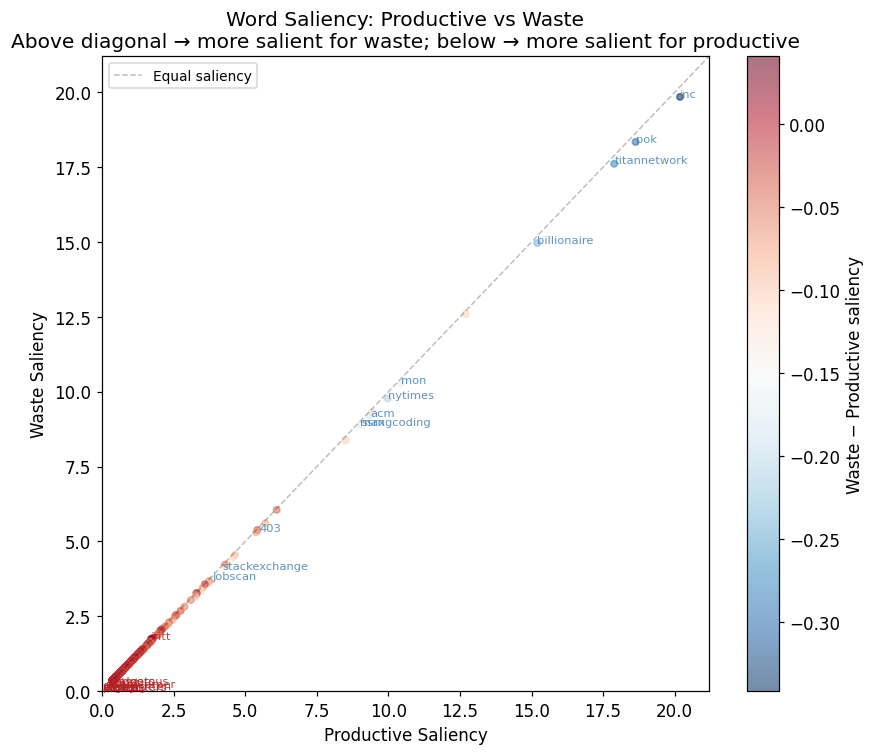

In [48]:

# ── 8.4b(ii) — Contrastive Word Saliency ─────────────────────────────────────

# Build a row per token: saliency toward productive, toward waste, and the difference
rows = []
for wid in set(word_sal_cls[0]) & set(word_sal_cls[1]):
    rows.append({
        'word':           idx2token_map.get(wid, f'<{wid}>'),
        'productive_sal': word_sal_cls[0][wid],
        'waste_sal':      word_sal_cls[1][wid],
    })
df_sal = pd.DataFrame(rows)
df_sal['diff'] = df_sal['waste_sal'] - df_sal['productive_sal']
df_sal = df_sal.sort_values('diff', ascending=False).reset_index(drop=True)

def print_sal_table(df, title, n=20):
    W = 22
    sep = '─' * (W + 38)
    print(f'\n{title}')
    print(sep)
    print(f'  {"Word":<{W}}  {"Prod Sal":>9}  {"Waste Sal":>9}  {"Diff":>9}')
    print(sep)
    for _, row in df.head(n).iterrows():
        print(f'  {row["word"][:W]:<{W}}  {row["productive_sal"]:>9.4f}'
              f'  {row["waste_sal"]:>9.4f}  {row["diff"]:>+9.4f}')
    print(sep)

print_sal_table(df_sal,                              '▲ Top 20 → WASTE       (diff = waste − productive, most positive first)')
print_sal_table(df_sal.tail(20).sort_values('diff'), '▼ Top 20 → PRODUCTIVE  (diff = waste − productive, most negative first)')

# ── Scatter: productive vs waste saliency ────────────────────────────────────
N_SCATTER = 300
top_ids = pd.concat([
    df_sal.nlargest(N_SCATTER, 'productive_sal'),
    df_sal.nlargest(N_SCATTER, 'waste_sal'),
]).drop_duplicates()

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(
    top_ids['productive_sal'], top_ids['waste_sal'],
    c=top_ids['diff'], cmap='RdBu_r', alpha=0.55, s=18,
)
plt.colorbar(sc, ax=ax, label='Waste − Productive saliency')

lim = max(top_ids['productive_sal'].max(), top_ids['waste_sal'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.25, lw=1, label='Equal saliency')
ax.set(
    xlabel='Productive Saliency', ylabel='Waste Saliency',
    xlim=[0, lim], ylim=[0, lim],
    title='Word Saliency: Productive vs Waste\nAbove diagonal → more salient for waste; below → more salient for productive',
)

N_LABEL = 12
for _, row in df_sal.head(N_LABEL).iterrows():
    ax.annotate(row['word'], (row['productive_sal'], row['waste_sal']),
                fontsize=7.5, color='firebrick', alpha=0.85)
for _, row in df_sal.tail(N_LABEL).iterrows():
    ax.annotate(row['word'], (row['productive_sal'], row['waste_sal']),
                fontsize=7.5, color='steelblue', alpha=0.85)

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'saliency_contrastive.png'), bbox_inches='tight')
plt.show()


### 8.4c — Interpretability: CNN Filter Activation Heatmap
Max filter activation per token position for each kernel size (k=3, 4, 5), shown for misclassified test pages.

Misclassified test samples: 24 / 183


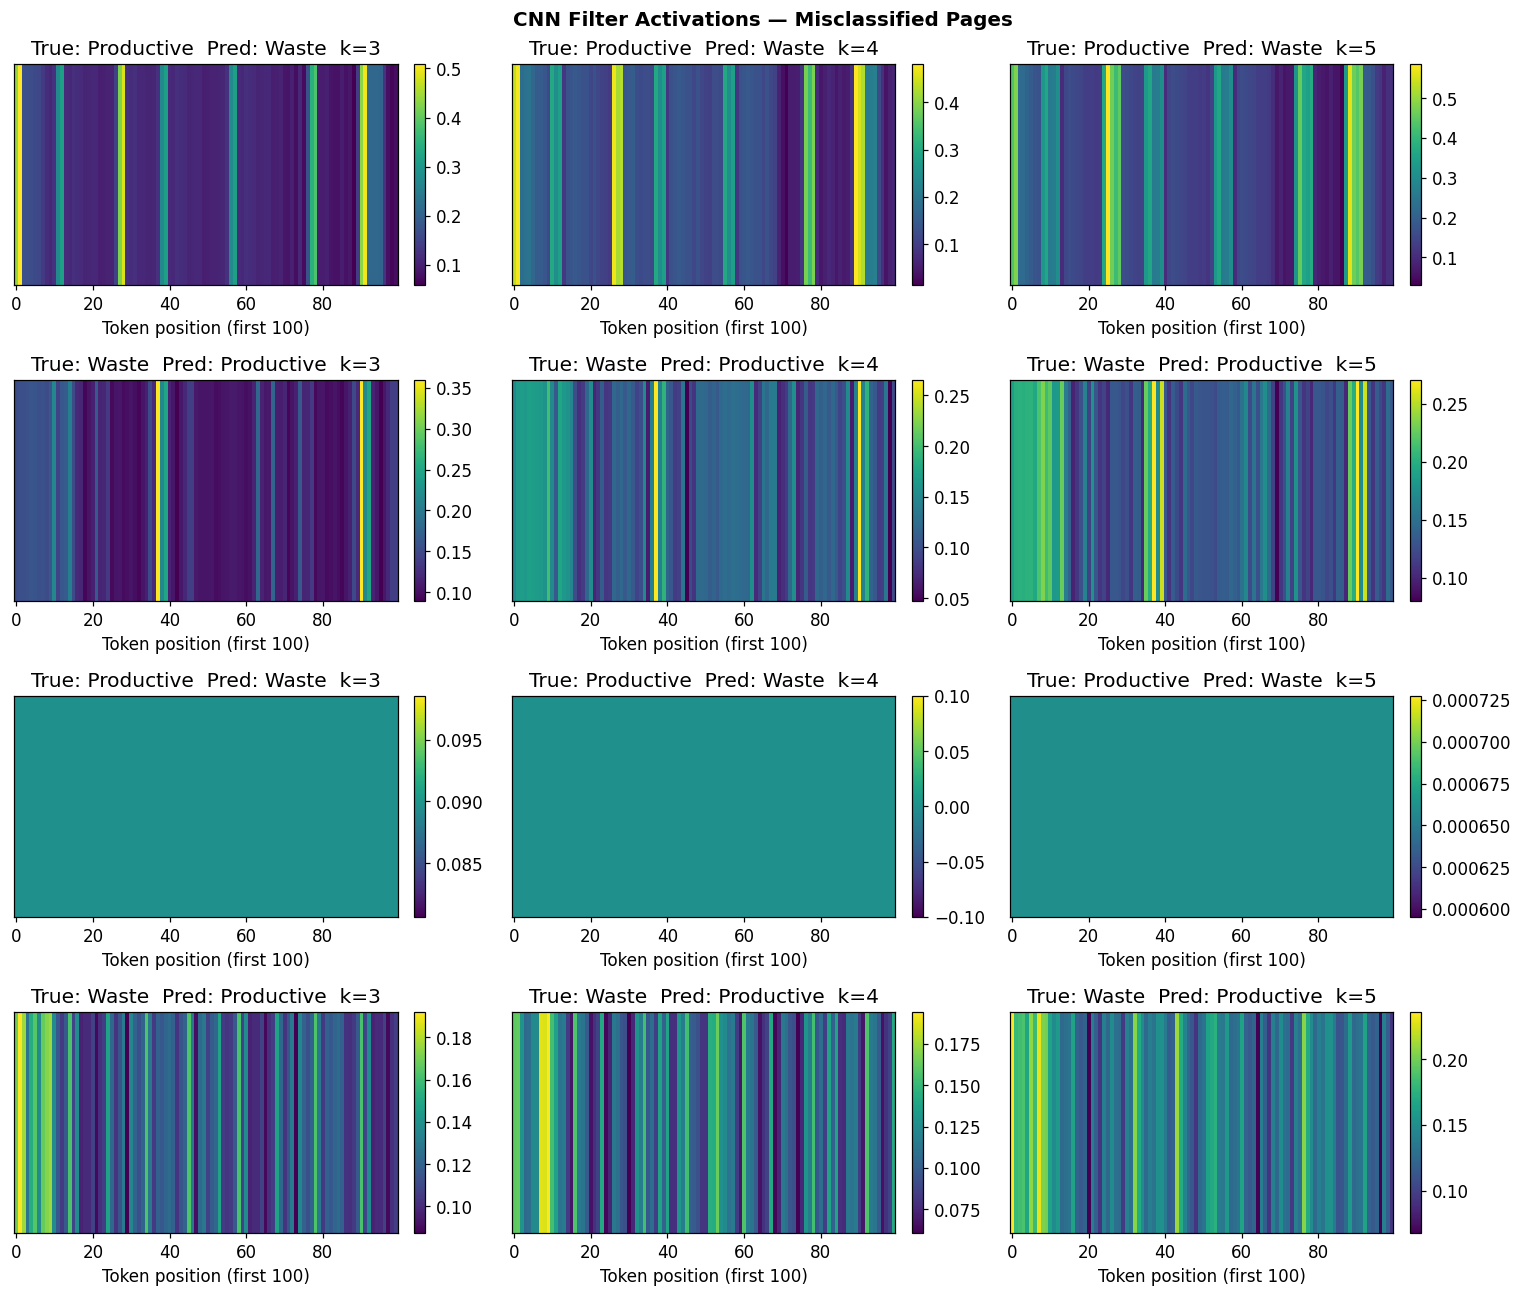

In [49]:

# ── Section 4C: CNN Filter Activation Heatmap (misclassified pages) ─────────
misclassified = np.where(test_labels_arr != test_preds_arr)[0]
print(f'Misclassified test samples: {len(misclassified)} / {len(test_labels_arr)}')

n_show = min(4, len(misclassified))
if n_show == 0:
    print('No misclassified samples — model got everything right on test set.')
else:
    fig, axes = plt.subplots(n_show, len(KERNEL_SIZES), figsize=(14, 3 * n_show))
    fig.suptitle('CNN Filter Activations — Misclassified Pages', fontsize=13, fontweight='bold')
    if n_show == 1:
        axes = axes[None, :]  # ensure 2D shape

    model.eval()
    for row, sample_idx in enumerate(misclassified[:n_show]):
        wi, ti, lbl = test_set[sample_idx]
        wi_in = wi.unsqueeze(0).to(DEVICE)
        ti_in = ti.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            we = model.word_emb(wi_in)
            se = model.struct_emb(ti_in)
            x  = torch.cat([we, se], dim=-1).permute(0, 2, 1)  # (1, k+n, M)

            for col, (conv, ks) in enumerate(zip(model.convs, KERNEL_SIZES)):
                acts     = model.relu(conv(x))[0]            # (F, seq_len')
                max_acts = acts.max(dim=0).values            # (seq_len',) max over filters
                display  = max_acts.cpu().numpy()
                display  = display[:min(100, len(display))]  # first 100 positions

                im = axes[row][col].imshow(display[None, :], aspect='auto', cmap='viridis')
                true_cls = CLASS_NAMES[lbl.item()]
                pred_cls = CLASS_NAMES[int(test_preds_arr[sample_idx])]
                axes[row][col].set(
                    title=f'True: {true_cls}  Pred: {pred_cls}  k={ks}',
                    yticks=[],
                    xlabel='Token position (first 100)',
                )
                plt.colorbar(im, ax=axes[row][col], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'filter_activations.png'), bbox_inches='tight')
    plt.show()


### 8.5–8.7 — Page-Level Analysis Setup
Builds `df_pages`: one row per test page with URL, true label, predicted label, P(waste), correctness, token list, and confidence score.
**Must run before sections 8.5, 8.6, and 8.7.**

In [50]:
# ── Page-level DataFrame ───────────────────────────────────────────────────
pages = []
for i in range(len(test_set)):
    dataset_idx = test_set.indices[i]
    url, _, _ = dataset.records[dataset_idx]
    word_idx, _, _ = test_set[i]
    tokens = [idx2token_map[wid] for wid in word_idx.numpy() if wid != 0]
    pages.append({
        'url':        url,
        'true_label': int(test_labels_arr[i]),
        'pred_label': int(test_preds_arr[i]),
        'p_waste':    float(test_probs_arr[i]),
        'correct':    bool(test_labels_arr[i] == test_preds_arr[i]),
        'tokens':     tokens,
    })

df_pages = pd.DataFrame(pages)
df_pages['confidence'] = df_pages.apply(
    lambda r: r['p_waste'] if r['true_label'] == 1 else 1 - r['p_waste'], axis=1
)

print(f'df_pages shape: {df_pages.shape}')
print(f'Correct productive : {len(df_pages[(df_pages.true_label==0) & df_pages.correct])}')
print(f'Correct waste      : {len(df_pages[(df_pages.true_label==1) & df_pages.correct])}')
print(f'False positives    : {len(df_pages[(df_pages.true_label==1) & ~df_pages.correct])}')
print(f'False negatives    : {len(df_pages[(df_pages.true_label==0) & ~df_pages.correct])}')


df_pages shape: (183, 7)
Correct productive : 84
Correct waste      : 75
False positives    : 13
False negatives    : 11


### 8.5 — Correct Prediction Insights
**5A** Correctly classified productive and waste pages sorted by confidence.
**5B** Token-frequency comparison: what vocabulary dominates each correct group.

In [51]:
# ── 8.5a — Correct Prediction Tables ──────────────────────────────────────
def _url(u, w=70):
    return (u[:w-1] + '…') if len(u) > w else u

def print_page_table(df_sub, conf_col_label, conf_col='confidence', n=None):
    rows = df_sub.sort_values(conf_col, ascending=False)
    if n:
        rows = rows.head(n)
    header = f"{'URL':<70}  {conf_col_label:>7}"
    print(header)
    print('─' * len(header))
    for _, r in rows.iterrows():
        print(f"{_url(r['url']):<70}  {r[conf_col]:7.4f}")

correct_prod = df_pages[(df_pages.true_label == 0) & df_pages.correct].copy()
correct_waste = df_pages[(df_pages.true_label == 1) & df_pages.correct].copy()

print(f'Correct Productive pages ({len(correct_prod)} total):')
print_page_table(correct_prod, 'P(prod)')
print()
print(f'Correct Waste pages ({len(correct_waste)} total):')
print_page_table(correct_waste, 'P(waste)')


Correct Productive pages (84 total):
URL                                                                     P(prod)
───────────────────────────────────────────────────────────────────────────────
https://salesduo.com/blog/check-fake-amazon-reviews/                     1.0000
https://researcher.life/blog/article/qualitative-vs-quantitative-rese…   1.0000
https://capd.mit.edu/resources/the-star-method-for-behavioral-intervi…   1.0000
https://www.fireboard.com/blog/maillard-reaction-where-flavor-and-tex…   1.0000
https://www.experian.com/blogs/ask-experian/avalanche-vs-snowball-whi…   1.0000
https://connex.digital/blog/automating-task-management-from-gmail-to-…   1.0000
https://www.lanchuhuong.com/data-and-code/2022-07-22_model-explainabi…   1.0000
https://paperpile.com/g/systematic-literature-review/                    1.0000
https://decentfoot.com/should-you-run-on-your-toes-or-heels/             1.0000
https://paisewaise.com/3-month-vs-6-month-emergency-fund/                1.0000
htt

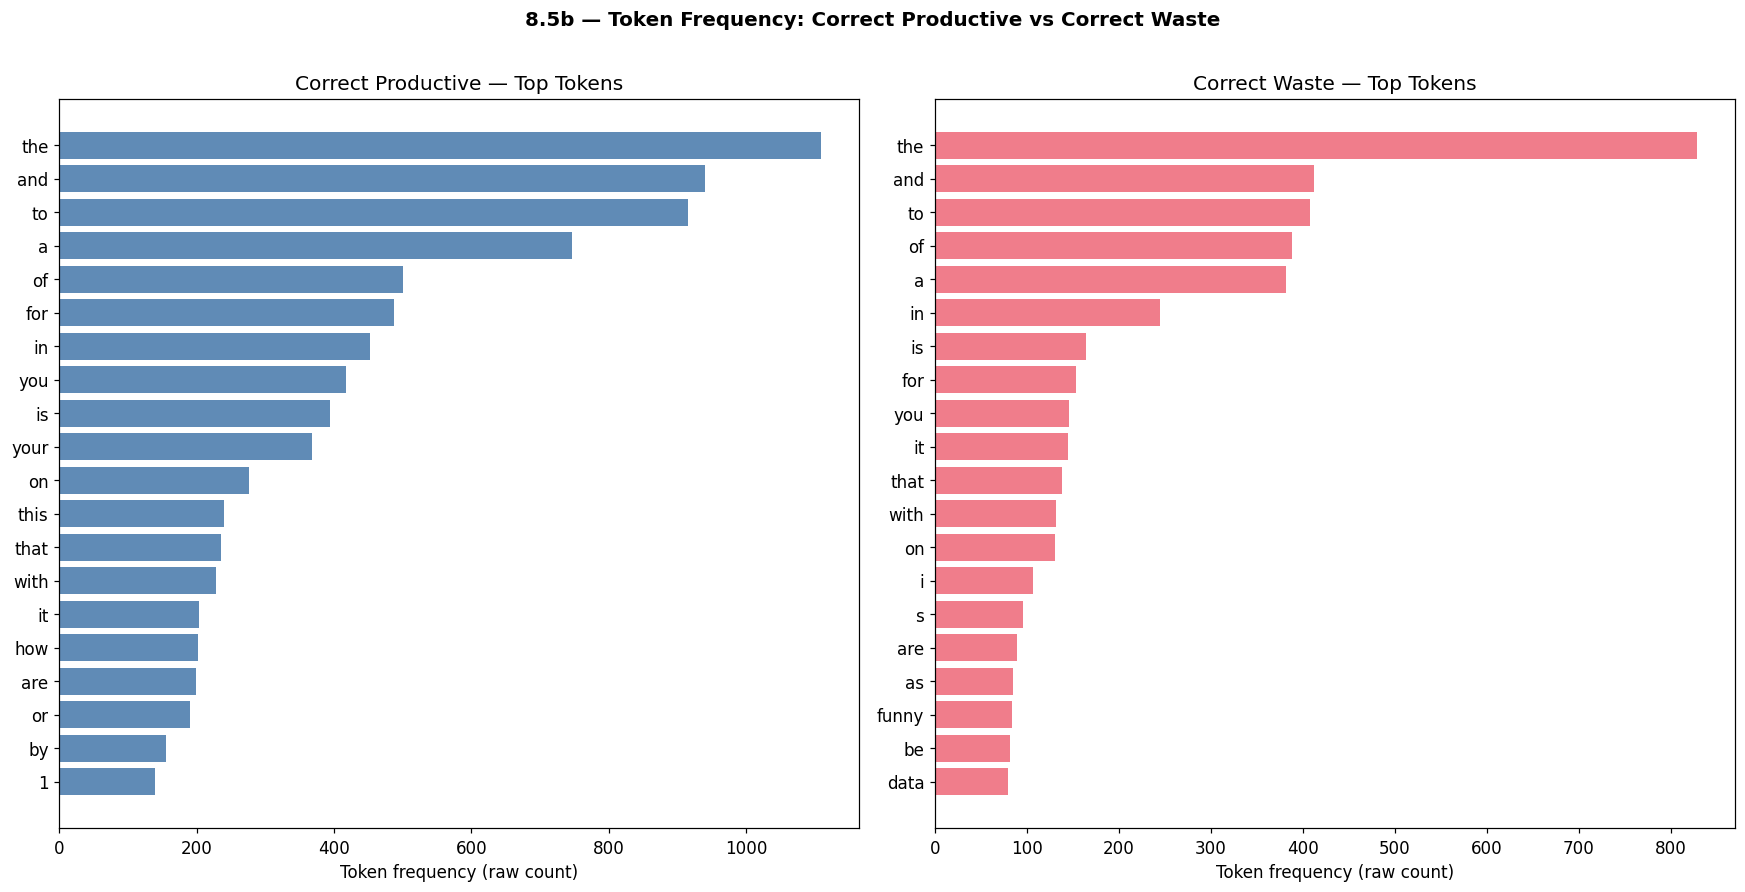

In [52]:
# ── 8.5b — Token Frequency Comparison (correct productive vs correct waste) ─
from collections import Counter

def top_tokens(df_sub, n=20):
    counts = Counter(t for toks in df_sub['tokens'] for t in toks)
    return counts.most_common(n)

prod_top  = top_tokens(correct_prod)
waste_top = top_tokens(correct_waste)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, top, title, color in [
    (axes[0], prod_top,  'Correct Productive — Top Tokens', '#4477AA'),
    (axes[1], waste_top, 'Correct Waste — Top Tokens',      '#EE6677'),
]:
    words, counts = zip(*top)
    ax.barh(range(len(words)), counts, color=color, alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_xlabel('Token frequency (raw count)')
    ax.set_title(title)

plt.suptitle('8.5b — Token Frequency: Correct Productive vs Correct Waste', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 8.6 — False Positives & False Negatives
**FP (waste→productive):** waste pages the model called productive.
**FN (productive→waste):** productive pages the model called waste.
**6A** Error tables with top page tokens. **6B** FP/FN token frequency comparison.

In [53]:
# ── 8.6a — Error Tables ────────────────────────────────────────────────────
STOPWORDS = {'the','a','an','and','or','of','in','to','is','it','for',
             'on','at','by','as','be','was','are','that','this','with'}

def page_top_tokens(tokens, n=5):
    counts = Counter(t for t in tokens if len(t) > 2 and t not in STOPWORDS)
    top = [w for w, _ in counts.most_common(n * 2)][:n]
    return ', '.join(top) if top else '—'

fp = df_pages[(df_pages.true_label == 1) & ~df_pages.correct].copy()  # waste called productive
fn = df_pages[(df_pages.true_label == 0) & ~df_pages.correct].copy()  # productive called waste

def print_error_table(df_err, p_col_label, p_col='p_waste', invert=False):
    df_err = df_err.sort_values(p_col, ascending=invert)
    header = f"{'URL':<70}  {p_col_label:>7}  Top tokens"
    print(header)
    print('─' * (len(header) + 20))
    for _, r in df_err.iterrows():
        p_val = (1 - r[p_col]) if invert else r[p_col]
        top_tok = page_top_tokens(r['tokens'])
        print(f"{_url(r['url']):<70}  {p_val:7.4f}  {top_tok}")

print(f'False Positives ({len(fp)}) — waste pages predicted as productive:')
print_error_table(fp, 'P(prod)', invert=True)
print()
print(f'False Negatives ({len(fn)}) — productive pages predicted as waste:')
print_error_table(fn, 'P(waste)', invert=False)


False Positives (13) — waste pages predicted as productive:
URL                                                                     P(prod)  Top tokens
───────────────────────────────────────────────────────────────────────────────────────────────────────────────
https://www.youtube.com/watch?v=ImQrPBlbWQA                              0.9978  desk, setup, live, ago, tech
https://www.grammy.com/news/taylor-swift-eras-tour-setlist-midnights-…   0.9972  tour, eras, grammy, swift's, taylor
https://www.youtube.com/watch?v=Eej_DqSFnhc                              0.9949  amazon, box, mystery, liquidation, unboxing
reddit.com/r/playboicarti/hot/                                           0.9944  post, removed, links, will, not
https://www.tumblr.com/badvisualisations                                 0.9929  here, what, from, you, there
reddit.com/r/digimon/                                                    0.9929  digimon, post, votes, comments, content
https://whatculture.com/amp/film/10-incr

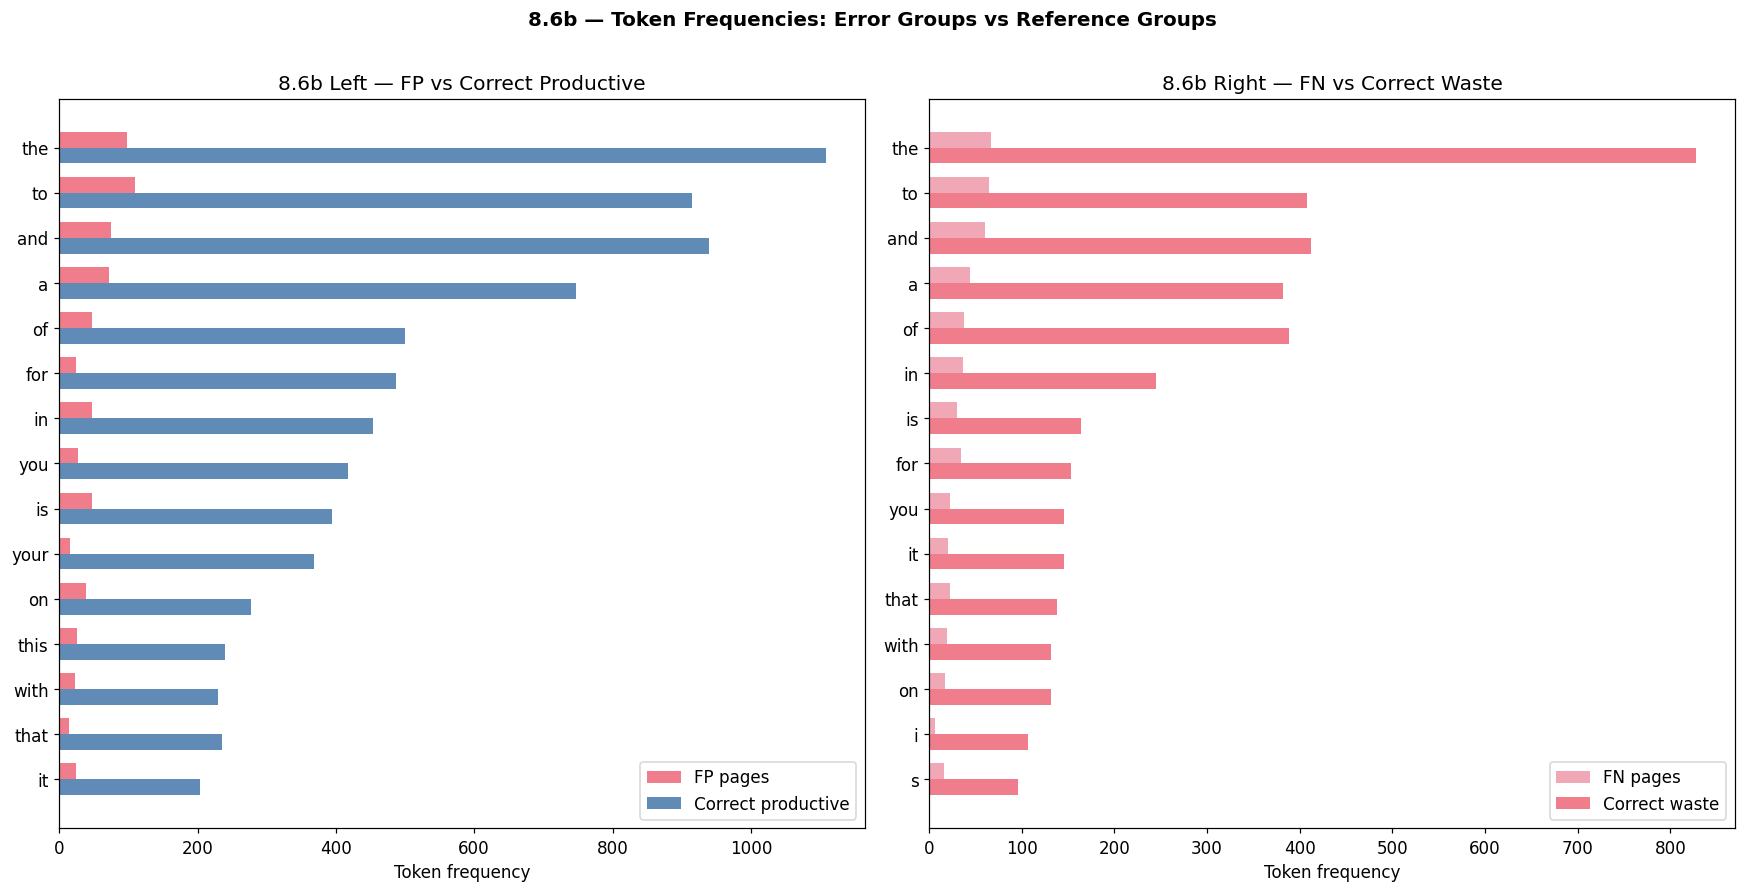

In [54]:
# ── 8.6b — FP vs FN Token Frequency Comparison ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

comparisons = [
    (axes[0], fp,           correct_prod,  'FP pages',        'Correct productive', '#EE6677', '#4477AA',
     '8.6b Left — FP vs Correct Productive'),
    (axes[1], fn,           correct_waste, 'FN pages',        'Correct waste',      '#EE99AA', '#EE6677',
     '8.6b Right — FN vs Correct Waste'),
]

for ax, df_err, df_ref, err_label, ref_label, err_color, ref_color, title in comparisons:
    err_counts  = Counter(t for toks in df_err['tokens']  for t in toks)
    ref_counts  = Counter(t for toks in df_ref['tokens']  for t in toks)
    # union of top-15 tokens from each group
    top_words = [w for w, _ in (err_counts + ref_counts).most_common(15)]
    err_vals  = [err_counts.get(w, 0) for w in top_words]
    ref_vals  = [ref_counts.get(w, 0) for w in top_words]
    y = range(len(top_words))
    bar_h = 0.35
    ax.barh([i - bar_h/2 for i in y], err_vals, bar_h, label=err_label, color=err_color, alpha=0.85)
    ax.barh([i + bar_h/2 for i in y], ref_vals, bar_h, label=ref_label, color=ref_color, alpha=0.85)
    ax.set_yticks(list(y))
    ax.set_yticklabels(top_words)
    ax.invert_yaxis()
    ax.set_xlabel('Token frequency')
    ax.set_title(title)
    ax.legend()

plt.suptitle('8.6b — Token Frequencies: Error Groups vs Reference Groups', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 8.7 — Confidence Distribution
**7A** Overlapping P(waste) histograms: correct productive, correct waste, and wrong predictions.
**7B** Tables: most confident correct, most confident wrong, most uncertain pages.

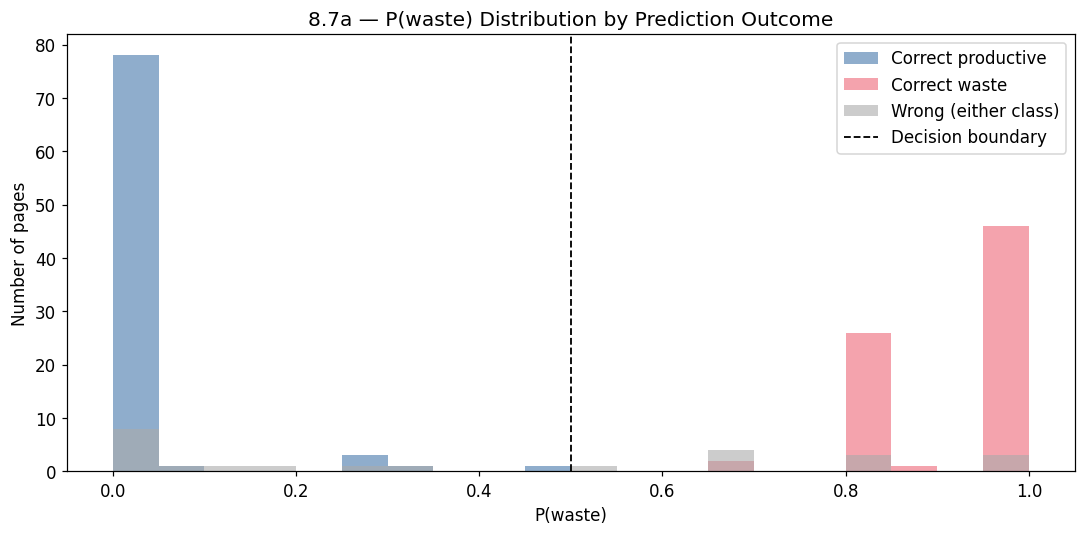

In [55]:
# ── 8.7a — Confidence Histogram ────────────────────────────────────────────
correct_prod_p  = df_pages[(df_pages.true_label == 0) & df_pages.correct]['p_waste'].values
correct_waste_p = df_pages[(df_pages.true_label == 1) & df_pages.correct]['p_waste'].values
wrong_p         = df_pages[~df_pages.correct]['p_waste'].values

fig, ax = plt.subplots(figsize=(10, 5))
bins = 20
ax.hist(correct_prod_p,  bins=bins, alpha=0.6, color='#4477AA', label='Correct productive', range=(0,1))
ax.hist(correct_waste_p, bins=bins, alpha=0.6, color='#EE6677', label='Correct waste',       range=(0,1))
ax.hist(wrong_p,         bins=bins, alpha=0.6, color='#AAAAAA', label='Wrong (either class)',range=(0,1))
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision boundary')
ax.set_xlabel('P(waste)')
ax.set_ylabel('Number of pages')
ax.set_title('8.7a — P(waste) Distribution by Prediction Outcome')
ax.legend()
plt.tight_layout()
plt.show()


In [56]:
# ── 8.7b — Confidence Tables ────────────────────────────────────────────────
label_name = {0: 'productive', 1: 'waste'}

# 1. Most confident correct
most_conf_correct_prod  = df_pages[(df_pages.true_label==0) & df_pages.correct].nlargest(5, 'confidence')
most_conf_correct_waste = df_pages[(df_pages.true_label==1) & df_pages.correct].nlargest(5, 'confidence')

print('Most confident correct — productive (top 5):')
header = f"{'URL':<70}  {'P(prod)':>7}"
print(header); print('─' * len(header))
for _, r in most_conf_correct_prod.iterrows():
    print(f"{_url(r['url']):<70}  {r['confidence']:7.4f}")

print()
print('Most confident correct — waste (top 5):')
header = f"{'URL':<70}  {'P(waste)':>8}"
print(header); print('─' * len(header))
for _, r in most_conf_correct_waste.iterrows():
    print(f"{_url(r['url']):<70}  {r['confidence']:8.4f}")

# 2. Most confident wrong
most_conf_wrong = df_pages[~df_pages.correct].nlargest(10, 'confidence')
print()
print('Most confident wrong (top 10) — dangerous errors:')
header = f"{'URL':<70}  {'True':>10}  {'Pred':>10}  {'P(wrong)':>8}"
print(header); print('─' * len(header))
for _, r in most_conf_wrong.iterrows():
    print(f"{_url(r['url']):<70}  {label_name[r['true_label']]:>10}  {label_name[r['pred_label']]:>10}  {r['confidence']:8.4f}")

# 3. Most uncertain
uncertain = df_pages[abs(df_pages['p_waste'] - 0.5) < 0.15].sort_values('p_waste')
print()
print(f'Most uncertain pages (|P(waste)−0.5| < 0.15, {len(uncertain)} pages):')
header = f"{'URL':<70}  {'True':>10}  {'P(waste)':>8}"
print(header); print('─' * len(header))
for _, r in uncertain.iterrows():
    print(f"{_url(r['url']):<70}  {label_name[r['true_label']]:>10}  {r['p_waste']:8.4f}")


Most confident correct — productive (top 5):
URL                                                                     P(prod)
───────────────────────────────────────────────────────────────────────────────
https://salesduo.com/blog/check-fake-amazon-reviews/                     1.0000
https://researcher.life/blog/article/qualitative-vs-quantitative-rese…   1.0000
https://capd.mit.edu/resources/the-star-method-for-behavioral-intervi…   1.0000
https://www.fireboard.com/blog/maillard-reaction-where-flavor-and-tex…   1.0000
https://www.experian.com/blogs/ask-experian/avalanche-vs-snowball-whi…   1.0000

Most confident correct — waste (top 5):
URL                                                                     P(waste)
────────────────────────────────────────────────────────────────────────────────
https://www.codeitbro.com/blog/best-data-science-memes-and-jokes          1.0000
https://www.theglobetrottergp.com/10-funny-travel-stories-fails/          1.0000
https://www.youtube.com/watch?